<a href="https://colab.research.google.com/github/Wartronick/3D-Printer-Failure-Detection/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **3D Printing Fault Detection: A Classical Pattern Recognition Approach with HOG and SVM Classifiers**

Author: ALEXANDRE DOMINGUES
---
Course: Pattern Recognition

Professor: André E. Lazzaretti

Program: PhD in Mobile Robotics (CPGEI)


---



This notebook details the development, implementation, and evaluation of a computer vision system for real-time fault detection in the additive manufacturing process (3D printing).

The problem addressed lies in the significant losses of time, material, and energy resulting from process anomalies, such as filament tangling or part detachment.The proposed solution is based on a classical Pattern Recognition approach to classify the print status from images captured by a camera.

The workflow documented in this notebook follows a canonical pipeline, starting with the loading and preprocessing of a custom image dataset.

Subsequently, visual feature extraction is performed using the HOG (Histogram of Oriented Gradients) descriptor, a robust technique for capturing shape and texture information. The next step consists of training and comparative evaluation of two supervised classifiers: Support Vector Machine (SVM) and Random Forest. Finally, the best-performing model is selected, saved, and validated in a real-time simulation, which includes an interactive tool for retraining and continuous model improvement (Active Learning).

Notebook Structure

---
*   Block 1: Environment Setup and Connection to Google Drive.
*   Block 2: Loading and Splitting the Image Dataset.
*   Block 3: Feature Extraction using the HOG descriptor.
*  Block 4: Training and Evaluation of the Support Vector Machine (SVM) Classifier.
*   Block 5: Training and Evaluation of the Random Forest Classifier for analysis.
*   Block 6: Selection and Saving of the Final Model (.joblib).
*   Block 7: Simulation of Continuous Real-Time Monitoring via video stream.
*  Block 8: Interactive Correction and Retraining Tool (Feedback Loop).
*   Block 9: Autonomous Logging Monitor for long-duration sessions.

---












..

Block 1: Environment Setup and Connection to Google Drive.

In [ ]:
# Block 1: Environment Setup and Connection to Google Drive.

# Importing essential libraries
print("Importing libraries...")
import os  # Para navegar e manipular pastas e arquivos
import tensorflow as tf  # Usaremos sua funcionalidade para carregar datasets de imagem
from google.colab import drive  # Módulo específico do Colab para montar o Google Drive
print("Libraries imported successfully.")

# Monta o Google Drive no ambiente do Colab.
# Uma janela de autorização do Google irá aparecer para você permitir o acesso.
print("\nConnecting to Google Drive...")
drive.mount('/content/drive')
print("Google Drive connected successfully.")

Importing libraries...
Libraries imported successfully.

Connecting to Google Drive...
Mounted at /content/drive
Google Drive connected successfully.


Block 2: Loading and Splitting the Image Dataset.

In [ ]:
# Block 2: Loading and Splitting the Image Dataset.

print("Starting the loading and splitting of your dataset...")

# --- Configuration Parameters ---

base_dir = "/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment's - Alexandre Domingues/Final Project/Final Project/Data Set"

# Image and batch parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# --- Automatic Loading and Splitting ---

# Loads the TRAINING set (80% of the data)
print(f"Loading and splitting data from: {base_dir}")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2, # Reserve 20% for validation
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    class_names=['NoDefects', 'YesDefects']
)

# Loads the VALIDATION set (the remaining 20%)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    class_names=['NoDefects', 'YesDefects']
)

print("\n--- Process Completed ---")
print("Classes found and order defined:", train_dataset.class_names)
print(f"The training dataset contains {tf.data.experimental.cardinality(train_dataset)} lots of ~{BATCH_SIZE} images.")
print(f"The validation dataset contains {tf.data.experimental.cardinality(validation_dataset)} lots of ~{BATCH_SIZE} images.")
print("Datasets ready for the next step!")

Starting the loading and splitting of your dataset...
Loading and splitting data from: /content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment's - Alexandre Domingues/Final Project/Final Project/Data Set
Found 516 files belonging to 2 classes.
Using 413 files for training.
Found 516 files belonging to 2 classes.
Using 103 files for validation.

--- Process Completed ---
Classes found and order defined: ['NoDefects', 'YesDefects']
The training dataset contains 13 lots of ~32 images.
The validation dataset contains 4 lots of ~32 images.
Datasets ready for the next step!


Block 3: Feature Extraction using the HOG descriptor.

In [ ]:
# Block 3: Feature Extraction with HOG (Histogram of Oriented Gradients)

import numpy as np
from skimage.feature import hog
import cv2

print("Initiating HOG feature extraction (with 16x16 cells)...")

def extract_hog_features(images, labels):
    """Iterates through a batch of images, converts them, and extracts HOG features."""
    hog_features = []
    hog_labels = []

    for image, label in zip(images, labels):
        # Convert from TensorFlow tensor to a NumPy array suitable for OpenCV
        image_np = image.numpy().astype('uint8')
        # Convert the image from RGB to grayscale
        gray_image = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)

        # HOG parameters: orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2).
        features = hog(gray_image, orientations=9, pixels_per_cell=(16, 16),
                       cells_per_block=(2, 2), transform_sqrt=True, block_norm='L2-Hys')

        hog_features.append(features)
        hog_labels.append(label.numpy())

    return hog_features, hog_labels

# Lists to store all features and labels from the datasets
all_train_features, all_train_labels = [], []
all_val_features, all_val_labels = [], []

print("Processing training set...")
# Iterate over each batch in the training dataset
for image_batch, label_batch in train_dataset:
    features, labels = extract_hog_features(image_batch, label_batch)
    all_train_features.extend(features)
    all_train_labels.extend(labels)

print("Processing validation set...")
# Iterate over each batch in the validation dataset
for image_batch, label_batch in validation_dataset:
    features, labels = extract_hog_features(image_batch, label_batch)
    all_val_features.extend(features)
    all_val_labels.extend(labels)

# Convert the feature lists into NumPy arrays for Scikit-learn
X_train = np.array(all_train_features)
y_train = np.array(all_train_labels)
X_val = np.array(all_val_features)
y_val = np.array(all_val_labels)

print("\n--- Feature Extraction Complete! ---")
print(f"Shape of training feature matrix (X_train): {X_train.shape}")
print(f"Shape of validation feature matrix (X_val): {X_val.shape}")

Initiating HOG feature extraction (with 16x16 cells)...
Processing training set...
Processing validation set...

--- Feature Extraction Complete! ---
Shape of training feature matrix (X_train): (413, 6084)
Shape of validation feature matrix (X_val): (103, 6084)


Block 4: Training and Evaluation of the Support Vector Machine (SVM) Classifier.

Initiating training of the SVM model (with class balancing)...
Training the model with 413 samples...
Training completed in 1.82 seconds.

Making predictions on the 103 validation samples...

Accuracy of the Balanced SVM Model: 99.03%

Detailed Classification Report:
              precision    recall  f1-score   support

   NoDefects       0.98      1.00      0.99        57
  YesDefects       1.00      0.98      0.99        46

    accuracy                           0.99       103
   macro avg       0.99      0.99      0.99       103
weighted avg       0.99      0.99      0.99       103


Confusion Matrix:


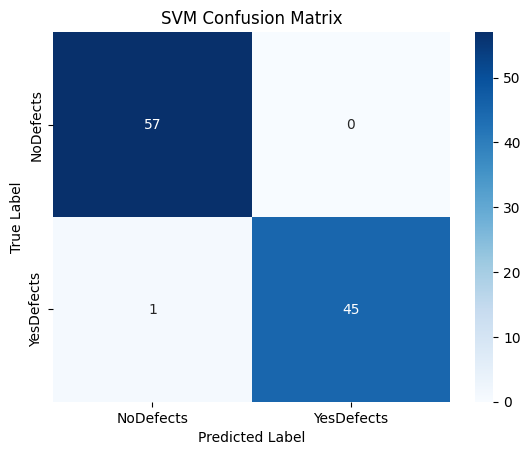

In [ ]:
# Block 4: SVM Classifier Training and Evaluation

# Importing the necessary libraries for this stage
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time
import seaborn as sns
import matplotlib.pyplot as plt

print("Initiating training of the SVM model (with class balancing)...")

# --- Model Training ---

# 1. Instantiate the SVM model with the balancing parameter.
#    This adjusts class weights inversely proportional to class frequencies.
model_svm_balanced = SVC(C=1.0, kernel='rbf', probability=True,
                         class_weight='balanced',  # The key strategy for our dataset!
                         random_state=42)

# 2. Train (fit) the model using the HOG features from the training set.
print(f"Training the model with {X_train.shape[0]} samples...")
start_time = time.time()
model_svm_balanced.fit(X_train, y_train)
end_time = time.time()
print(f"Training completed in {end_time - start_time:.2f} seconds.")

# --- Model Evaluation ---

# 3. Make predictions on the validation set (unseen data).
print(f"\nMaking predictions on the {X_val.shape[0]} validation samples...")
y_pred = model_svm_balanced.predict(X_val)

# 4. Calculate and display the performance metrics.
accuracy = accuracy_score(y_val, y_pred)
print(f"\nAccuracy of the Balanced SVM Model: {accuracy * 100:.2f}%")

# The Classification Report provides the most important metrics.
print("\nDetailed Classification Report:")
# We use 'train_dataset.class_names' to display the correct class names in the report.
print(classification_report(y_val, y_pred, target_names=train_dataset.class_names))


# Bonus: Visualizing the Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.class_names,
            yticklabels=train_dataset.class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix')
plt.show()

Block 5: Training and Evaluation of the Random Forest Classifier for analysis.

Initiating training of the Random Forest model (with class balancing)...
Training the model with 413 samples...
Training completed in 1.13 seconds.

Making predictions on the 103 validation samples...

Accuracy of the Random Forest Model: 98.06%

Detailed Classification Report (Random Forest):
              precision    recall  f1-score   support

   NoDefects       0.98      0.98      0.98        57
  YesDefects       0.98      0.98      0.98        46

    accuracy                           0.98       103
   macro avg       0.98      0.98      0.98       103
weighted avg       0.98      0.98      0.98       103


Confusion Matrix (Random Forest):


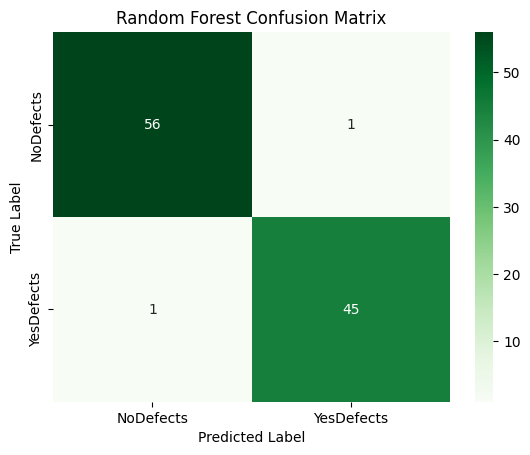

In [ ]:
# Block 5: Random Forest Classifier Training and Evaluation

# Importing the Random Forest classifier
from sklearn.ensemble import RandomForestClassifier
import time

print("Initiating training of the Random Forest model (with class balancing)...")

# --- Model Training ---

# 1. Instantiate the model with the balancing parameter.
#    n_estimators: the number of decision trees in the forest.
model_rf = RandomForestClassifier(n_estimators=100,
                                  class_weight='balanced',
                                  random_state=42,
                                  n_jobs=-1)  # n_jobs=-1: Use all available CPU cores to speed up training.

# 2. Train the model using the same HOG features from the training set.
print(f"Training the model with {X_train.shape[0]} samples...")
start_time = time.time()
model_rf.fit(X_train, y_train)
end_time = time.time()
print(f"Training completed in {end_time - start_time:.2f} seconds.")

# --- Model Evaluation ---

# 3. Make predictions on the validation set.
print(f"\nMaking predictions on the {X_val.shape[0]} validation samples...")
y_pred_rf = model_rf.predict(X_val)

# 4. Calculate and display the performance metrics.
accuracy_rf = accuracy_score(y_val, y_pred_rf)
print(f"\nAccuracy of the Random Forest Model: {accuracy_rf * 100:.2f}%")

print("\nDetailed Classification Report (Random Forest):")
print(classification_report(y_val, y_pred_rf, target_names=train_dataset.class_names))

# Bonus: Visualizing the Confusion Matrix
print("\nConfusion Matrix (Random Forest):")
cm_rf = confusion_matrix(y_val, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=train_dataset.class_names,
            yticklabels=train_dataset.class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix')
plt.show()

Block 6: Final Model Serialization

In [ ]:
import os
import joblib

# CORRECT path to the project folder (based on your drive structure)
# We removed "/Data Set" from the end to save it in the project root
project_folder = "/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment's - Alexandre Domingues/Final Project/Final Project/"

# Filename for the model
model_filename = "svm_defect_detector_v1.joblib"

# Full path to save the file
model_path = os.path.join(project_folder, model_filename)

print(f"Attempting to save model to: {model_path}")

# Save the model
joblib.dump(model_svm_balanced, model_path)

print(f"✅ Model (SVM) successfully saved!")

Attempting to save model to: /content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment's - Alexandre Domingues/Final Project/Final Project/svm_defect_detector_v1.joblib
✅ Model (SVM) successfully saved!


Block 7: Simulation of Continuous Real-Time Monitoring via video stream.

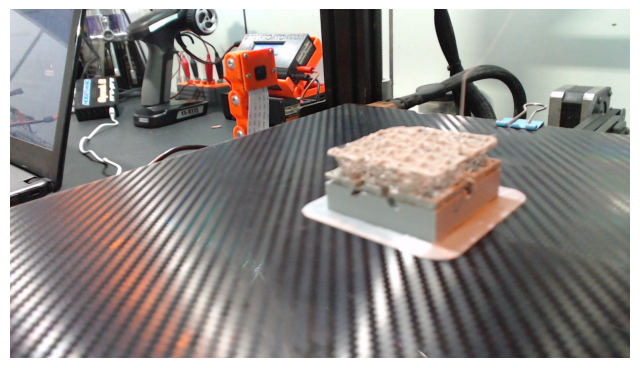

Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not reconnect to stream. Retrying...
Could not r

In [ ]:
# --- Block 7: Real-Time Monitoring  ---

import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import cv2
import numpy as np
from skimage.feature import hog
import joblib

# --- Configuration ---
# This function defines the HOG feature extraction pipeline for a single frame.
def process_frame(frame):
    """Applies preprocessing and HOG feature extraction to a single frame."""
    resized_frame = cv2.resize(frame, (224, 224))
    gray_frame = cv2.cvtColor(resized_frame, cv2.COLOR_BGR2GRAY)
    features = hog(gray_frame, orientations=9, pixels_per_cell=(16, 16),
                   cells_per_block=(2, 2), transform_sqrt=True, block_norm='L2-Hys')
    return features

# --- Model Loading ---
# Load the trained model before entering the main loop.
try:
    model_path = "/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment's - Alexandre Domingues/Final Project/Final Project/svm_defect_detector_v1.joblib"
    loaded_model = joblib.load(model_path)
    print("Model successfully loaded!")
except Exception as e:
    print(f"❌ ERROR: Failed to load the model. Details: {e}")
    raise

print("\nInitiating continuous monitoring mode...")
print("Press the STOP button in the cell to halt execution.")

# Global variables to pass data to the correction block (Block 8)
global last_frame_captured, last_hog_features

try:
    # --- Live Stream Configuration ---
    # IMPORTANT: Ensure this is the current public URL from your tunnel service.
    stream_url = "https://millennium-candle-deputy-shortly.trycloudflare.com/?action=stream"

    while True:
        # CRITICAL CHANGE: The capture object is created INSIDE the loop to fetch a fresh frame every time.
        cap = cv2.VideoCapture(stream_url)
        if not cap.isOpened():
            print("Could not reconnect to stream. Retrying...")
            time.sleep(2) # Wait 2 seconds before retrying
            continue # Skip to the next loop iteration

        ret, frame = cap.read()

        # CRITICAL CHANGE: The capture object is released IMMEDIATELY after grabbing one frame.
        cap.release()

        if not ret:
            print("Could not capture frame. Retrying...")
            time.sleep(2)
            continue

        # Store the latest data for the external correction block (Block 8)
        last_frame_captured = frame
        last_hog_features = process_frame(frame)

        # --- Inference ---
        hog_features_reshaped = last_hog_features.reshape(1, -1)
        prediction = loaded_model.predict(hog_features_reshaped)
        probability = loaded_model.predict_proba(hog_features_reshaped)
        predicted_class_index = prediction[0]
        confidence = probability[0][predicted_class_index] * 100

        # --- Display Results ---
        clear_output(wait=True)
        print("--- REAL-TIME MONITORING ---")
        print(f"Model Prediction: '{train_dataset.class_names[predicted_class_index]}")
        # (Confidence: {confidence:.2f}%)")

        # Convert frame from BGR (OpenCV) to RGB (Matplotlib) for correct color display
        frame_rgb = cv2.cvtColor(last_frame_captured, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 6))
        plt.imshow(frame_rgb)
        plt.axis('off')
        plt.show()

        time.sleep(1)

except KeyboardInterrupt:
    print("\nMonitoring interrupted by user.")
except Exception as e:
    print(f"\nAn error occurred: {e}")
finally:
    # Ensure the camera connection is released if the loop is interrupted
    if 'cap' in locals() and 'cap' in vars() and cap.isOpened():
        cap.release()
        print("Camera connection released.")

Block 8: Interactive Correction and Retraining Tool

In [ ]:
# Block 8: Interactive Correction and Retraining Tool

import os
import datetime
import time
import joblib # Ensures joblib is imported for saving the model

try:
    print("--- INITIATING CORRECTION AND RETRAINING ---")

    # User confirmation prompt
    print("\nYou are about to correct the classification for the LAST frame displayed by the monitor.")

    # Ask for the ground truth label from the user
    correct_label_str = input("What was the correct class for the image? (0 for NoDefects, 1 for YesDefects): ")

    # Process the user's feedback
    correct_label = int(correct_label_str)
    if correct_label not in [0, 1]: raise ValueError("Invalid class index.")

    correct_class_name = train_dataset.class_names[correct_label]

    # Save the misclassified frame to the correct dataset folder on Google Drive
    save_path = os.path.join(base_dir, correct_class_name)
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = os.path.join(save_path, f"retrain_{timestamp}.jpg")
    cv2.imwrite(filename, last_frame_captured)
    print(f"Image saved to: {filename}")

    # Add the new sample to the training data and retrain the model
    print("Augmenting training data and retraining the SVM model...")
    X_train = np.vstack([X_train, last_hog_features])
    y_train = np.append(y_train, correct_label)

    start_time = time.time()
    model_svm_balanced.fit(X_train, y_train)
    end_time = time.time()

    # Update the in-memory model and overwrite the saved model file
    loaded_model = model_svm_balanced
    joblib.dump(loaded_model, model_path)

    print(f"✅ Model successfully retrained and saved in {end_time - start_time:.2f} seconds!")

except NameError:
    print("ERROR: Block 7 does not appear to have been run first. Please run the monitor to capture an image before providing feedback.")
except (ValueError, IndexError):
    print("Invalid input. Skipping retraining.")
except Exception as e:
    print(f"An error occurred: {e}")

--- INITIATING CORRECTION AND RETRAINING ---

You are about to correct the classification for the LAST frame displayed by the monitor.
What was the correct class for the image? (0 for NoDefects, 1 for YesDefects): 
Invalid input. Skipping retraining.


Block 9: Autonomous Logging Monitor for long-duration sessions.

In [ ]:
# --- Block 9: Autonomous Logging Monitor with OSD (Temporary Storage) ---

import time
import cv2
import numpy as np
import datetime
import os
from IPython.display import clear_output

# --- 1. LOGGING SETUP ---
# Creates a unique directory for this session in the local Colab environment.
run_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
log_dir = f"log_run_{run_timestamp}"
os.makedirs(log_dir, exist_ok=True)

# Creates a subdirectory for the captured images.
log_image_dir = os.path.join(log_dir, "captured_images")
os.makedirs(log_image_dir, exist_ok=True)

# Defines the path for the CSV log file.
csv_log_path = os.path.join(log_dir, "log_impressao.csv")

# Writes the header row to the CSV file.
with open(csv_log_path, 'w') as f:
    f.write("Timestamp,Prediction,Confidence,ImagePath\n")

print(f"✅ Initializing Monitoring. Data will be saved to the temporary directory:")
print(f"{log_dir}")
print("REMINDER: Download this folder before the session ends, as the data is temporary.")
print("Press the STOP button in the cell to halt monitoring.")

# --- MONITORING LOOP ---
try:
    # IMPORTANT: Ensure this is the current public URL from your tunnel service.
    stream_url = "https://degree-ccd-drawings-continued.trycloudflare.com/?action=stream"

    while True:
        cap = cv2.VideoCapture(stream_url)
        if not cap.isOpened():
            print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Could not reconnect to stream...")
            time.sleep(30)
            continue

        ret, frame = cap.read()
        cap.release()

        if not ret:
            print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Could not capture frame...")
            time.sleep(30)
            continue

        # --- 2. Image Analysis ---
        hog_features = process_frame(frame)
        hog_features_reshaped = hog_features.reshape(1, -1)
        prediction = loaded_model.predict(hog_features_reshaped)
        probability = loaded_model.predict_proba(hog_features_reshaped)
        predicted_class_index = prediction[0]
        predicted_class_name = train_dataset.class_names[predicted_class_index]
        confidence = probability[0][predicted_class_index]

        current_time_obj = datetime.datetime.now()
        current_time_str = current_time_obj.strftime("%Y-%m-%d %H:%M:%S")

        print(f"[{current_time_str}] Status: {predicted_class_name} (Confidence: {confidence:.2f})")

        # --- 3. ON-SCREEN DISPLAY (OSD) ANNOTATION ---

        if predicted_class_name == 'NoDefects':
            text_color = (0, 255, 0) # Green in BGR format
        else:
            text_color = (0, 0, 255) # Red in BGR format

        status_text = f"Status: {predicted_class_name}"
        confidence_text = f"Confidence: {confidence:.2f}"
        timestamp_text = current_time_str

        cv2.rectangle(frame, (0,0), (frame.shape[1], 120), (0,0,0), -1)

        cv2.putText(frame, status_text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, text_color, 2, cv2.LINE_AA)
        cv2.putText(frame, confidence_text, (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 1.2, text_color, 2, cv2.LINE_AA)
        cv2.putText(frame, timestamp_text, (frame.shape[1] - 550, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2, cv2.LINE_AA)

        # --- 4. Data Logging (CSV and Image with OSD) ---
        image_timestamp = current_time_obj.strftime("%Y%m%d_%H%M%S")
        image_filename = f"{image_timestamp}.jpg"
        image_log_path = os.path.join(log_image_dir, image_filename)

        # Save the annotated frame.
        cv2.imwrite(image_log_path, frame)

        if predicted_class_index == 1:
            print(f"  -> 🚨 ALERT: DEFECT DETECTED! Image saved to: {image_log_path}")

        log_entry = f"{current_time_str},{predicted_class_name},{confidence:.4f},{image_log_path}\n"

        with open(csv_log_path, 'a') as f:
            f.write(log_entry)

        # Interval between each analysis cycle.
        time.sleep(30)

except KeyboardInterrupt:
    print("\nMonitoring interrupted by user.")
except Exception as e:
    print(f"\nAn error occurred: {e}")

✅ Initializing Monitoring. Data will be saved to the temporary directory:
log_run_20251017_225751
REMINDER: Download this folder before the session ends, as the data is temporary.
Press the STOP button in the cell to halt monitoring.
[2025-10-17 22:57:53] Status: NoDefects (Confidence: 0.95)
[2025-10-17 22:58:25] Status: NoDefects (Confidence: 0.98)

Monitoring interrupted by user.
